## XGBoost Model

In [20]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.metrics import precision_score, recall_score, f1_score
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

# Set display options
pd.set_option('display.max_columns', None)
plt.style.use('default')

In [21]:
df = pd.read_csv("../data/processed/model_ready.csv")

In [ ]:
# Define target and feature columns
target = 'final_four'
features = [
    'barthag',
    'adj_o',
    'adj_d',
    'adj_t',
    'seed_filled',
    'elite_seed',
    'wab',
    'ov_cur_sos'
]

X = df[features]
y = df[target]

print(f"Number of features: {len(features)}")
print(f"Number of samples: {len(df)}")
print(f"\nFeature columns: {features[:10]}")

Number of features: 8
Number of samples: 5607

Feature columns: ['barthag', 'adj_o', 'adj_d', 'adj_t', 'seed_filled', 'elite_seed', 'wab', 'ov_cur_sos']


In [23]:
# Time-based split - Train on 2008-2021, Test on 2022-2024
train_mask = df['year'] <= 2021
test_mask = df['year'] >= 2022

X_train = df[train_mask][features]
X_test = df[test_mask][features]
y_train = df[train_mask][target]
y_test = df[test_mask][target]

print("="*50)
print("TIME-BASED TRAIN-TEST SPLIT")
print("="*50)
print(f"\nTraining years: {sorted(df[train_mask]['year'].unique())}")
print(f"Test years: {sorted(df[test_mask]['year'].unique())}")
print(f"\nTraining set size: {len(X_train)}")
print(f"Test set size: {len(X_test)}")
print(f"\nTraining set Final Four teams: {y_train.sum()}")
print(f"Test set Final Four teams: {y_test.sum()}")

TIME-BASED TRAIN-TEST SPLIT

Training years: [2008, 2009, 2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2021]
Test years: [2022, 2023, 2024]

Training set size: 4524
Test set size: 1083

Training set Final Four teams: 52
Test set Final Four teams: 12


SMOTE RESAMPLING

Class distribution BEFORE SMOTE:
final_four
0    4472
1      52
Name: count, dtype: int64

Class distribution AFTER SMOTE:
final_four
0    4472
1     894
Name: count, dtype: int64

Original training set size: 4524
Resampled training set size: 5366


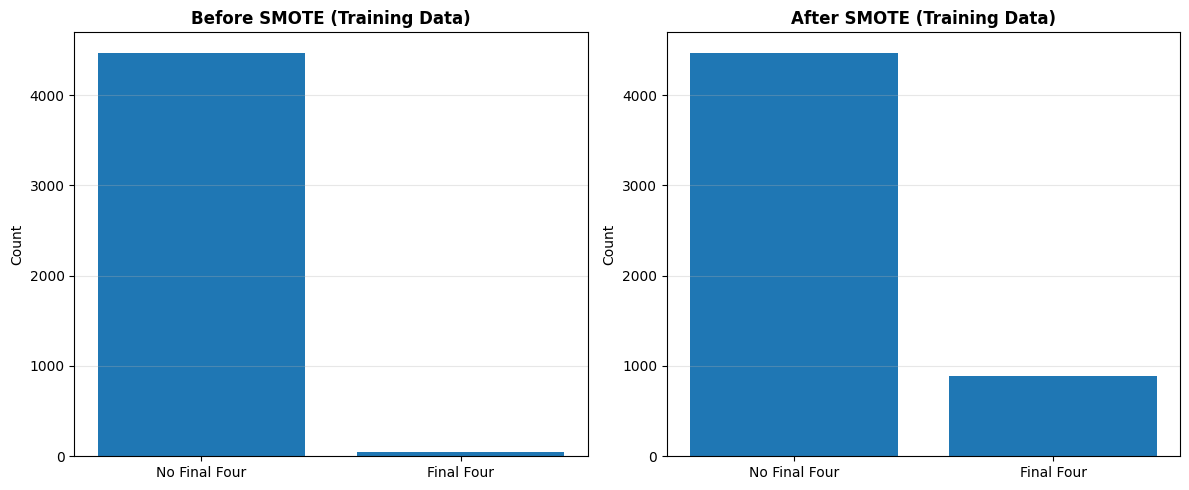

In [24]:
# Apply SMOTE to training data only
smote = SMOTE(random_state=42, sampling_strategy=0.2)  # 20% ratio instead of 1.0 (50-50)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)

print("="*50)
print("SMOTE RESAMPLING")
print("="*50)
print("\nClass distribution BEFORE SMOTE:")
print(y_train.value_counts())
print(f"\nClass distribution AFTER SMOTE:")
print(pd.Series(y_train_resampled).value_counts())
print(f"\nOriginal training set size: {len(X_train)}")
print(f"Resampled training set size: {len(X_train_resampled)}")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].bar(['No Final Four', 'Final Four'], y_train.value_counts().sort_index())
axes[0].set_title('Before SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3, axis='y')

axes[1].bar(['No Final Four', 'Final Four'], 
            pd.Series(y_train_resampled).value_counts().sort_index())
axes[1].set_title('After SMOTE (Training Data)', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

In [25]:
# Calculate scale_pos_weight for class imbalance (even though using SMOTE)
# This is XGBoost's way of handling imbalance
scale_pos_weight = (y_train_resampled == 0).sum() / (y_train_resampled == 1).sum()
print(f"Scale pos weight: {scale_pos_weight:.2f}")

# Train XGBoost with good default parameters
xgb_model = xgb.XGBClassifier(
    n_estimators=200,           # Number of boosting rounds
    max_depth=6,                # Maximum tree depth (prevent overfitting)
    learning_rate=0.1,          # Step size shrinkage (0.01-0.3)
    subsample=0.8,              # Fraction of samples for each tree
    colsample_bytree=0.8,       # Fraction of features for each tree
    min_child_weight=3,         # Minimum sum of instance weight in a child
    gamma=0,                    # Minimum loss reduction for split
    reg_alpha=0,                # L1 regularization
    reg_lambda=1,               # L2 regularization
    scale_pos_weight=1,         # Using SMOTE, so set to 1 (or use scale_pos_weight calculated above)
    random_state=42,
    eval_metric='logloss',      # Evaluation metric
    use_label_encoder=False,
    n_jobs=-1
)

print("Training XGBoost model...")
xgb_model.fit(
    X_train_resampled, 
    y_train_resampled,
    verbose=False
)

print("✓ Model trained successfully!")
print(f"Number of boosting rounds: {xgb_model.n_estimators}")
print(f"Number of features used: {xgb_model.n_features_in_}")

Scale pos weight: 5.00
Training XGBoost model...


c:\Users\conno\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:05:45] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


✓ Model trained successfully!
Number of boosting rounds: 200
Number of features used: 8


In [26]:
# Make predictions on test set (2022-2024)
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1]

print("="*50)
print("PREDICTIONS ON TEST SET (2022-2024)")
print("="*50)
print(f"Predicted Final Four teams: {y_pred.sum()}")
print(f"Actual Final Four teams: {y_test.sum()}")
print(f"Prediction rate: {y_pred.sum() / len(y_pred):.2%}")
print(f"Actual rate: {y_test.sum() / len(y_test):.2%}")

PREDICTIONS ON TEST SET (2022-2024)
Predicted Final Four teams: 13
Actual Final Four teams: 12
Prediction rate: 1.20%
Actual rate: 1.11%


CONFUSION MATRIX (Default Threshold = 0.5)
[[1064    7]
 [   6    6]]


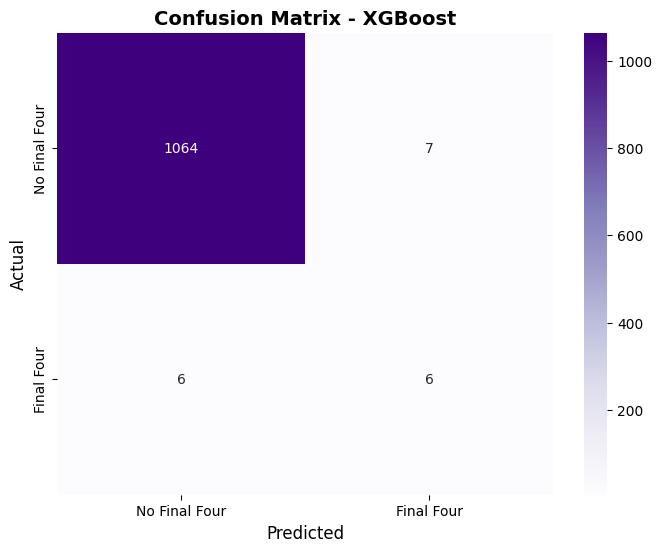

In [27]:
# Confusion Matrix with default 0.5 threshold
print("="*50)
print("CONFUSION MATRIX (Default Threshold = 0.5)")
print("="*50)

cm = confusion_matrix(y_test, y_pred)
print(cm)

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'])
plt.title('Confusion Matrix - XGBoost', fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [28]:
# Classification Report
print("="*50)
print("CLASSIFICATION REPORT (Default Threshold)")
print("="*50)
print(classification_report(y_test, y_pred))

CLASSIFICATION REPORT (Default Threshold)
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      1071
           1       0.46      0.50      0.48        12

    accuracy                           0.99      1083
   macro avg       0.73      0.75      0.74      1083
weighted avg       0.99      0.99      0.99      1083



ROC-AUC Score: 0.9525


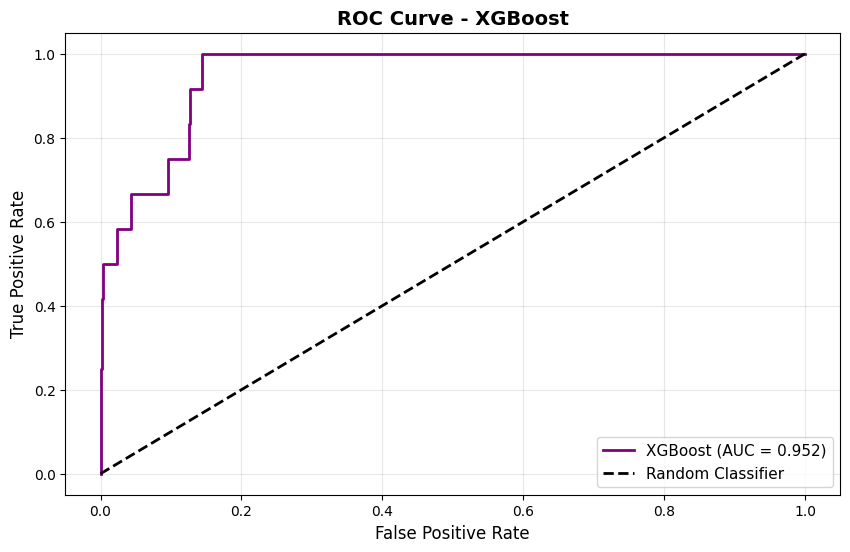

In [29]:
# ROC-AUC Score
roc_auc = roc_auc_score(y_test, y_pred_proba)
print(f"ROC-AUC Score: {roc_auc:.4f}")

# ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)

plt.figure(figsize=(10, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {roc_auc:.3f})', color='purple')
plt.plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - XGBoost', fontsize=14, fontweight='bold')
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.show()

THRESHOLD ANALYSIS


,Threshold,Predicted,True Pos,False Pos,False Neg,Precision,Recall,F1-Score
0,0.30,17,6,11,6,0.352941,0.500000,0.413793
1,0.40,15,6,9,6,0.400000,0.500000,0.444444
2,0.50,13,6,7,6,0.461538,0.500000,0.480000
3,0.60,9,5,4,7,0.555556,0.416667,0.476190
4,0.70,7,5,2,7,0.714286,0.416667,0.526316
5,0.80,7,5,2,7,0.714286,0.416667,0.526316
6,0.90,4,3,1,9,0.750000,0.250000,0.375000
7,0.95,3,2,1,10,0.666667,0.166667,0.266667


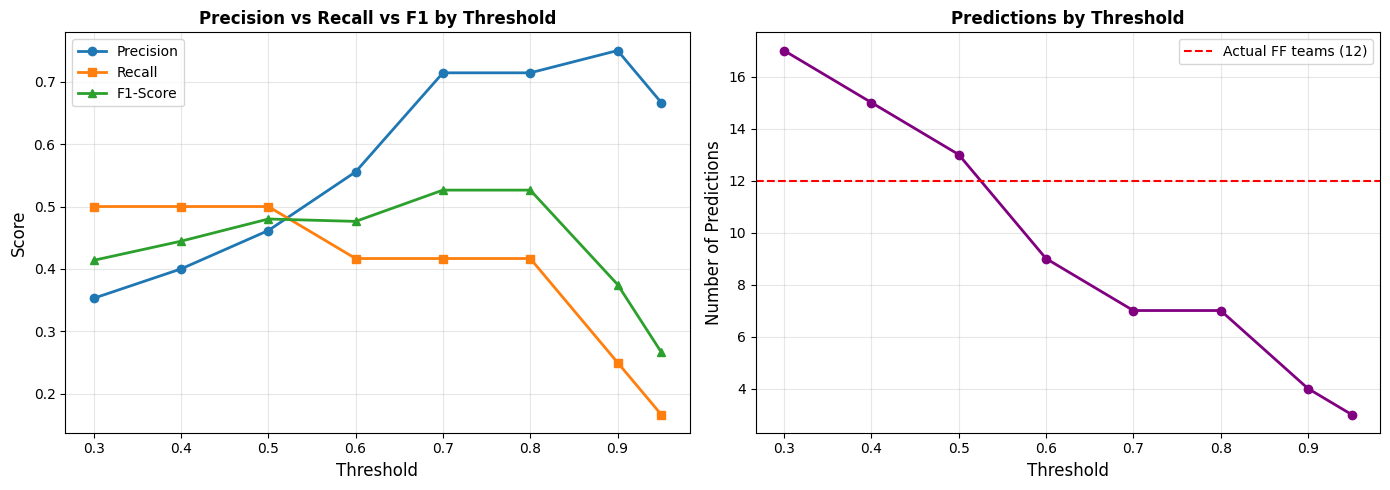

In [30]:
# Test different thresholds to find the sweet spot
print("="*50)
print("THRESHOLD ANALYSIS")
print("="*50)

thresholds_to_test = [0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]
results_list = []

for thresh in thresholds_to_test:
    y_pred_thresh = (y_pred_proba >= thresh).astype(int)
    cm_thresh = confusion_matrix(y_test, y_pred_thresh)
    
    tn, fp, fn, tp = cm_thresh.ravel()
    precision = precision_score(y_test, y_pred_thresh, zero_division=0)
    recall = recall_score(y_test, y_pred_thresh, zero_division=0)
    f1 = f1_score(y_test, y_pred_thresh, zero_division=0)
    
    results_list.append({
        'Threshold': thresh,
        'Predicted': y_pred_thresh.sum(),
        'True Pos': tp,
        'False Pos': fp,
        'False Neg': fn,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1
    })

threshold_df = pd.DataFrame(results_list)
display(threshold_df)

# Visualize threshold impact
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Precision vs Recall
axes[0].plot(threshold_df['Threshold'], threshold_df['Precision'], 'o-', label='Precision', linewidth=2)
axes[0].plot(threshold_df['Threshold'], threshold_df['Recall'], 's-', label='Recall', linewidth=2)
axes[0].plot(threshold_df['Threshold'], threshold_df['F1-Score'], '^-', label='F1-Score', linewidth=2)
axes[0].set_xlabel('Threshold', fontsize=12)
axes[0].set_ylabel('Score', fontsize=12)
axes[0].set_title('Precision vs Recall vs F1 by Threshold', fontsize=12, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Number of predictions
axes[1].plot(threshold_df['Threshold'], threshold_df['Predicted'], 'o-', linewidth=2, color='purple')
axes[1].axhline(y=12, color='red', linestyle='--', label='Actual FF teams (12)')
axes[1].set_xlabel('Threshold', fontsize=12)
axes[1].set_ylabel('Number of Predictions', fontsize=12)
axes[1].set_title('Predictions by Threshold', fontsize=12, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

RESULTS WITH OPTIMAL THRESHOLD = 0.6

Confusion Matrix:
[[1067    4]
 [   7    5]]

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1071
           1       0.56      0.42      0.48        12

    accuracy                           0.99      1083
   macro avg       0.77      0.71      0.74      1083
weighted avg       0.99      0.99      0.99      1083



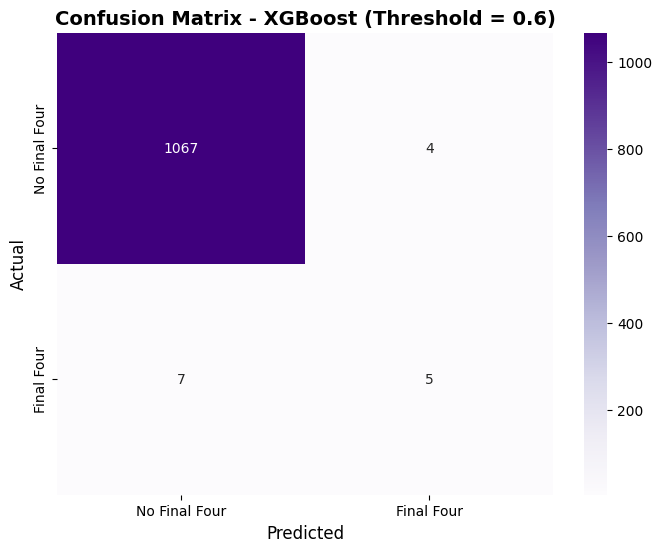

In [31]:
# Choose your optimal threshold based on the analysis above
optimal_threshold = 0.6  # Adjust based on Cell 12 results

y_pred_optimal = (y_pred_proba >= optimal_threshold).astype(int)

print("="*50)
print(f"RESULTS WITH OPTIMAL THRESHOLD = {optimal_threshold}")
print("="*50)

cm_optimal = confusion_matrix(y_test, y_pred_optimal)
print("\nConfusion Matrix:")
print(cm_optimal)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_optimal))

# Visualize
plt.figure(figsize=(8, 6))
sns.heatmap(cm_optimal, annot=True, fmt='d', cmap='Purples', 
            xticklabels=['No Final Four', 'Final Four'],
            yticklabels=['No Final Four', 'Final Four'])
plt.title(f'Confusion Matrix - XGBoost (Threshold = {optimal_threshold})', 
          fontsize=14, fontweight='bold')
plt.ylabel('Actual', fontsize=12)
plt.xlabel('Predicted', fontsize=12)
plt.show()

In [33]:
# Feature importance from XGBoost
# XGBoost has multiple importance types: 'weight', 'gain', 'cover'
feature_importance = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_  # Default is 'weight'
}).sort_values('importance', ascending=False)

print("="*50)
print("FEATURE IMPORTANCE")
print("="*50)
display(feature_importance.head(20))

# Summary statistics
print(f"\nTotal features: {len(feature_importance)}")
print(f"Top 10 features account for: {feature_importance.head(10)['importance'].sum():.2%} of importance")

FEATURE IMPORTANCE


,feature,importance
0,barthag,0.544454
4,seed_filled,0.214679
3,adj_t,0.059910
2,adj_d,0.044372
1,adj_o,0.042568
5,elite_seed,0.034991
7,ov_cur_sos,0.032775
6,wab,0.026251



Total features: 8
Top 10 features account for: 100.00% of importance


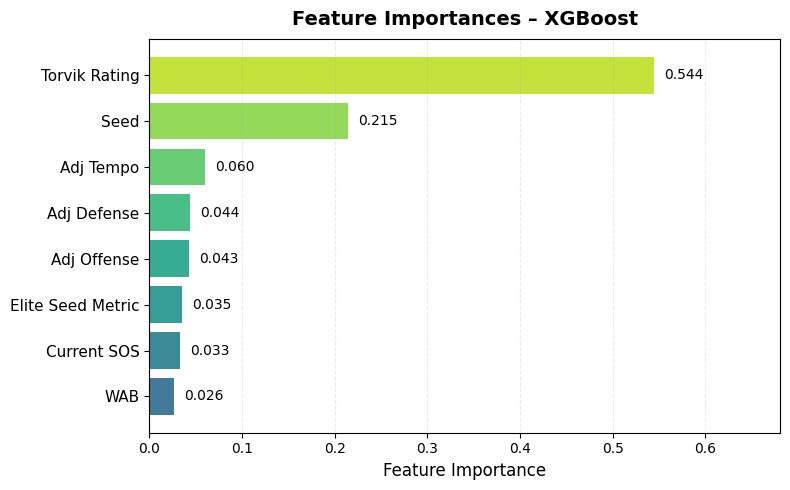

In [45]:
label_map = {
    "barthag": "Torvik Rating",
    "seed_filled": "Seed",
    "adj_t": "Adj Tempo",
    "adj_d": "Adj Defense",
    "adj_o": "Adj Offense",
    "elite_seed": "Elite Seed Metric",
    "ov_cur_sos": "Current SOS",
    "wab": "WAB"
}
df['clean_label'] = df['feature'].map(label_map).fillna(df['feature'])

plt.figure(figsize=(8, 5))
ax = plt.gca()

y_pos = np.arange(len(df))
colors = plt.cm.viridis(np.linspace(0.35, 0.9, len(df)))
bars = ax.barh(y_pos, df['importance'], color=colors, alpha=0.9)


max_val = df['importance'].max()
ax.set_xlim(0, max_val * 1.25)

ax.set_yticks(y_pos)
ax.set_yticklabels(df['clean_label'], fontsize=11)

ax.set_xlabel('Feature Importance', fontsize=12)
ax.set_title('Feature Importances – XGBoost', fontsize=14, fontweight='bold', pad=10)

ax.grid(axis='x', linestyle='--', alpha=0.25)


for bar, val in zip(bars, df['importance']):
    ax.text(
        val + max_val * 0.02,
        bar.get_y() + bar.get_height() / 2,
        f'{val:.3f}',
        va='center',
        fontsize=10
    )

plt.tight_layout()
plt.show()